In [6]:
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Lasso

In [7]:
# 加载数据
yale = loadmat('data_aug.mat')
#载入YALE32mat文件的方法，得到的x是一个字典，可以print一下他的shape看一下里面的属性

In [8]:
X = yale['data']

y = yale['labels'].T.flatten()     #将数据展开


In [9]:
# 使用LassoCV进行特征选择
lasso = Lasso(alpha=0.00004)
lasso.fit(X, y)

/mnt/5468e/ypzhang/.conda/envs/wss_torch/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.130e-02, tolerance: 1.500e-03
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive


Lasso(alpha=4e-05)

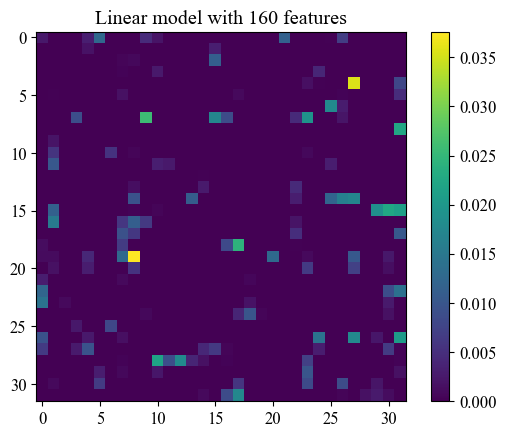

In [10]:
# 输出特征选择结果
from matplotlib import rcParams
importances = abs(lasso.coef_) / np.sum(abs(lasso.coef_))
num = np.count_nonzero(importances)
config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(32, 32).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/yale_lasso_selected.pdf", bbox_inches='tight')
plt.show()